In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

In [3]:
data_dir = Path("./req_2160_batch_8_817")
model_setting = "70b_batch_8"

## Speed (performance?)

Processing latency-only
Processing rebatching
Processing median
Processing eager
Processing lazy
Processing median
Processing eager
Processing lazy
Processing latency-only
Processing off
Processing rebatching
Found 11 data points to plot.
          policy layer conf  throughput  bert_score
0   latency-only    50  0.7  116.258160    0.787181
1     rebatching    50  0.9  123.460680    0.802941
2         median    50  0.7  117.990436    0.807615
3          eager    50  0.7  156.288567    0.711175
4           lazy    50  0.7  116.038897    0.815048
5         median    50  0.9  116.645809    0.812652
6          eager    50  0.9  155.231653    0.711268
7           lazy    50  0.9  115.219439    0.815483
8   latency-only    50  0.9  116.489893    0.801327
9            off    50  0.9  116.842895    0.811746
10    rebatching    50  0.7  133.176991    0.773056


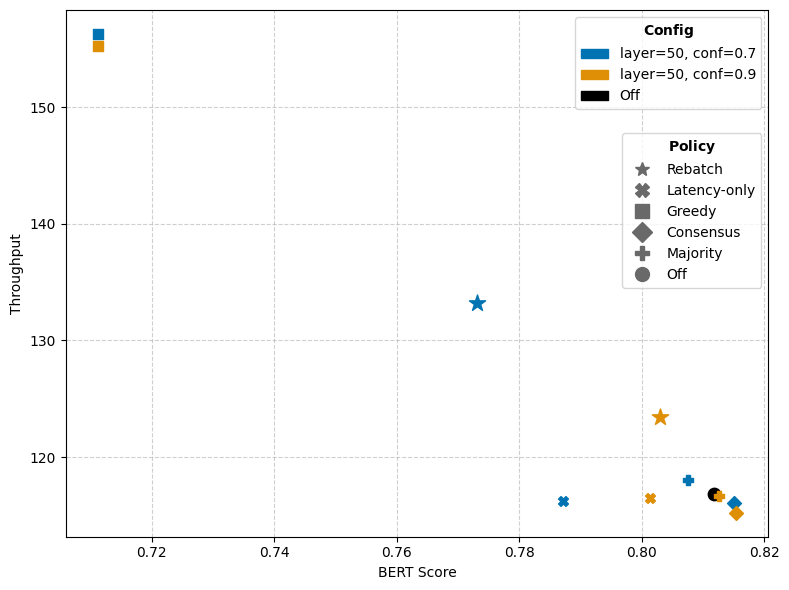

In [6]:
def plot_throughput_vs_bert_from_csvs(data_dir):
    """
    Plots throughput vs. BERT score, creating two separate legends for
    policies (markers) and configurations (colors) stacked together in the
    upper-right corner of the figure.
    """
    # Define policies, configs, and their visual properties
    policies = {
        "rebatching": {"label": "Rebatch", "marker": "*"},
        "eager": {"label": "Greedy", "marker": "s"},
        "lazy": {"label": "Consensus", "marker": "D"},
        "median": {"label": "Majority", "marker": "P"},
        "latency-only": {"label": "Latency-only", "marker": "X"},
        "off": {"label": "Off", "marker": "o"},
    }
    # Define the specific configs and their associated colors
    palette = sns.color_palette("colorblind", n_colors=2)
    config_color_map = {
        ("50", "0.7"): palette[0],
        ("50", "0.9"): palette[1],
    }

    # --- Data Preparation ---
    rows = []
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)
    

    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name

        if fname == "req_2160_batch_8_layer_50_conf_0.7_rebatching_copy.csv":
            continue


        m = re.search(r"layer_([0-9]+)_conf_([0-9.]+)_([a-z\-]+)_copy\.csv$", fname)
        if m:
            layer, conf, policy = m.group(1), m.group(2), m.group(3)

            print(f"Processing {policy}")

            if policy not in policies:
                continue
            if policy != 'off' and (layer, conf) not in config_color_map:
                continue
            
            try:
                df = pd.read_csv(csv_path)
            except:
                print(f"Error reading {csv_path}")
                
            
            throughput = df["throughput"].mean()
            bert_score = df["bert_score"].mean()


            rows.append({
                "policy": policy,
                "layer": layer,
                "conf": conf,
                "throughput": throughput,
                "bert_score": bert_score,
            })

    plot_df = pd.DataFrame(rows)
    print(f"Found {len(plot_df)} data points to plot.")
    print(plot_df)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the 'off' policy data point
    subdf_off = plot_df[plot_df["policy"] == "off"]
    if not subdf_off.empty:
        ax.scatter(
            subdf_off["bert_score"], subdf_off["throughput"],
            marker=policies["off"]["marker"], color="black", s=80, zorder=3
        )

    # Plot data points for other policies and configs
    for policy, p_info in policies.items():
        if policy == "off":
            continue
        for (layer, conf), color in config_color_map.items():
            subdf = plot_df[
                (plot_df["policy"] == policy) &
                (plot_df["layer"] == layer) &
                (plot_df["conf"] == conf)
            ]
            if not subdf.empty:
                if policy == "rebatching":
                    ax.scatter(
                        subdf["bert_score"], subdf["throughput"],
                        marker=p_info["marker"], color=color, s=150, zorder=3
                    )
                else:
                    ax.scatter(
                        subdf["bert_score"], subdf["throughput"],
                        marker=p_info["marker"], color=color, s=50, zorder=3
                    )


    # --- Manual Legend Creation in Upper Right Corner ---

    # 1. Create handles for the "Config" legend (colors)
    config_handles = [
        mpatches.Patch(color=palette[0], label="layer=50, conf=0.7"),
        mpatches.Patch(color=palette[1], label="layer=50, conf=0.9"),
        mpatches.Patch(color='black', label="Off")
    ]
    # Create the first legend and specify its location
    config_legend = ax.legend(handles=config_handles, title="$\\bf{Config}$",
                              loc='upper right', bbox_to_anchor=(1, 1))

    # **Add the first legend to the axes manually**
    ax.add_artist(config_legend)

    # 2. Create handles for the "Policy" legend (markers)
    policy_order = ["rebatching", "latency-only", "eager", "lazy", "median", "off"]
    policy_handles = [
        mlines.Line2D([], [], color='dimgrey', marker=policies[p]['marker'],
                      linestyle='None', markersize=10, label=policies[p]['label'])
        for p in policy_order
    ]
    # Create the second legend, placing it below the first one by adjusting
    # the vertical component of `bbox_to_anchor`.
    ax.legend(handles=policy_handles, title="$\\bf{Policy}$",
              loc='upper right', bbox_to_anchor=(1, 0.78))

    # --- Final Touches ---
    ax.set_xlabel("BERT Score")
    ax.set_ylabel("Throughput")
    #ax.set_title("Throughput vs. BERT Score by Policy and Configuration")
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
plot_throughput_vs_bert_from_csvs(data_dir)

Processing latency-only
Processing rebatching
Processing median
Processing eager
Processing lazy
Processing median
Processing eager
Processing lazy
Processing latency-only
Processing off
Processing rebatching
Found 11 data points to plot.
          policy layer conf  throughput  bert_score
0   latency-only    50  0.7  116.258160    0.787181
1     rebatching    50  0.9  123.460680    0.802941
2         median    50  0.7  117.990436    0.807615
3          eager    50  0.7  156.288567    0.711175
4           lazy    50  0.7  116.038897    0.815048
5         median    50  0.9  116.645809    0.812652
6          eager    50  0.9  155.231653    0.711268
7           lazy    50  0.9  115.219439    0.815483
8   latency-only    50  0.9  116.489893    0.801327
9            off    50  0.9  116.842895    0.811746
10    rebatching    50  0.7  133.176991    0.773056


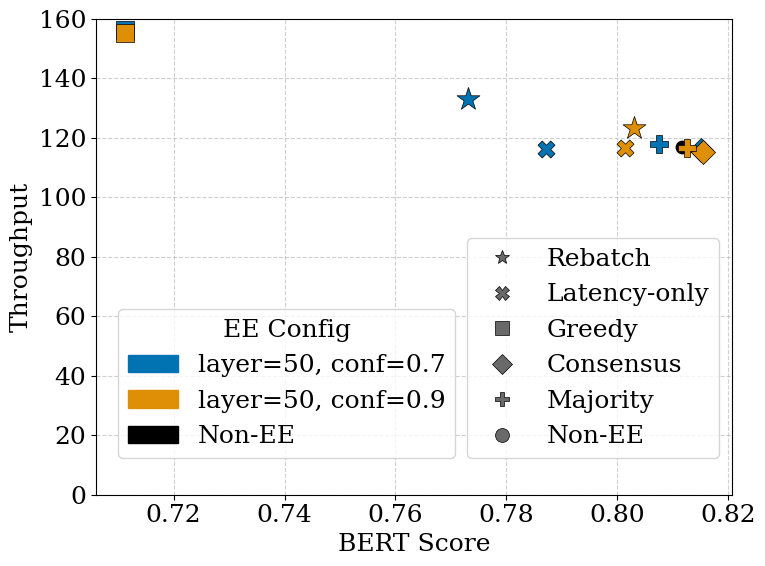

In [7]:
def plot_throughput_vs_bert_from_csvs(data_dir):
    """
    Plots throughput vs. BERT score, creating two separate legends for
    policies (markers) and configurations (colors) stacked together in the
    upper-right corner of the figure.
    """
    plt.rc("font", size=18, family="serif")
    # Define policies, configs, and their visual properties
    policies = {
        "rebatching": {"label": "Rebatch", "marker": "*"},
        "eager": {"label": "Greedy", "marker": "s"},
        "lazy": {"label": "Consensus", "marker": "D"},
        "median": {"label": "Majority", "marker": "P"},
        "latency-only": {"label": "Latency-only", "marker": "X"},
        "off": {"label": "Non-EE", "marker": "o"},
    }
    # Define the specific configs and their associated colors
    palette = sns.color_palette("colorblind", n_colors=2)
    config_color_map = {
        ("50", "0.7"): palette[0],
        ("50", "0.9"): palette[1],
    }

    # --- Data Preparation ---
    rows = []
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        if fname == "req_2160_batch_8_layer_50_conf_0.7_rebatching_copy.csv":
            continue
        m = re.search(r"layer_([0-9]+)_conf_([0-9.]+)_([a-z\-]+)_copy\.csv$", fname)
        if m:
            layer, conf, policy = m.group(1), m.group(2), m.group(3)

            print(f"Processing {policy}")

            if policy not in policies:
                continue
            if policy != 'off' and (layer, conf) not in config_color_map:
                continue
            
            try:
                df = pd.read_csv(csv_path)
            except:
                print(f"Error reading {csv_path}")
                
            
            throughput = df["throughput"].mean()
            bert_score = df["bert_score"].mean()
            rows.append({
                "policy": policy,
                "layer": layer,
                "conf": conf,
                "throughput": throughput,
                "bert_score": bert_score,
            })

    plot_df = pd.DataFrame(rows)
    print(f"Found {len(plot_df)} data points to plot.")
    print(plot_df)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the 'off' policy data point
    subdf_off = plot_df[plot_df["policy"] == "off"]
    if not subdf_off.empty:
        ax.scatter(
            subdf_off["bert_score"], subdf_off["throughput"],
            marker=policies["off"]["marker"], color="black", s=80, zorder=3
        )

    # Plot data points for other policies and configs
    for policy, p_info in policies.items():
        if policy == "off":
            continue
        for (layer, conf), color in config_color_map.items():
            subdf = plot_df[
                (plot_df["policy"] == policy) &
                (plot_df["layer"] == layer) &
                (plot_df["conf"] == conf)
            ]
            if not subdf.empty:
                if policy == "rebatching":
                    ax.scatter(
                        subdf["bert_score"], subdf["throughput"],
                        marker=p_info["marker"], color=color, s=300, zorder=3,
                        edgecolors='black',
                        linewidths=0.5,
                        label=p_info["label"]
                    )
                else:
                    ax.scatter(
                        subdf["bert_score"], subdf["throughput"],
                        marker=p_info["marker"], color=color, s=150, zorder=3,
                        edgecolors='black',
                        linewidths=0.5,
                        label=p_info["label"]
                    )


    # --- Manual Legend Creation in Upper Right Corner ---

    # 1. Create handles for the "Config" legend (colors)
    config_handles = [
        mpatches.Patch(color=palette[0], label="layer=50, conf=0.7"),
        mpatches.Patch(color=palette[1], label="layer=50, conf=0.9"),
        mpatches.Patch(color='black', label="Non-EE")
    ]
    # Create the first legend and specify its location
    config_legend = ax.legend(handles=config_handles, title="EE Config",
                              loc='lower center', bbox_to_anchor=(0.3, 0.05))

    # **Add the first legend to the axes manually**
    ax.add_artist(config_legend)

    # 2. Create handles for the "Policy" legend (markers)
    policy_order = ["rebatching", "latency-only", "eager", "lazy", "median", "off"]
    policy_handles = [
        mlines.Line2D([], [], color='dimgrey', marker=policies[p]['marker'],
                      linestyle='None', markersize=10, label=policies[p]['label'],
                    markeredgecolor='black',
                              markeredgewidth=0.5)
        for p in policy_order
    ]
    # Create the second legend, placing it below the first one by adjusting
    # the vertical component of `bbox_to_anchor`.
    ax.legend(handles=policy_handles,
              loc='lower right', bbox_to_anchor=(1, 0.05))

    # --- Final Touches ---
    ax.set_xlabel("BERT Score")
    ax.set_ylabel("Throughput")
    #ax.set_title("Throughput vs. BERT Score by Policy and Configuration")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_ylim(0, 160)
    plt.tight_layout()
    plt.savefig(f"figures/throughput_vs_bert/throughput_vs_bert_{model_setting}.pdf", bbox_inches='tight')
    plt.show()
plot_throughput_vs_bert_from_csvs(data_dir)

Found 11 data points to plot.
          policy layer conf  throughput  p95_conf_score
0   latency-only    50  0.7  116.258160        0.767920
1     rebatching    50  0.9  123.460680        0.912109
2         median    50  0.7  117.990436        0.006344
3          eager    50  0.7  156.288567        0.020325
4           lazy    50  0.7  116.038897        0.758008
5         median    50  0.9  116.645809        0.008781
6          eager    50  0.9  155.231653        0.019917
7           lazy    50  0.9  115.219439        0.922852
8   latency-only    50  0.9  116.489893        0.984668
9            off    50  0.9  116.842895        1.000000
10    rebatching    50  0.7  133.176991        0.750488


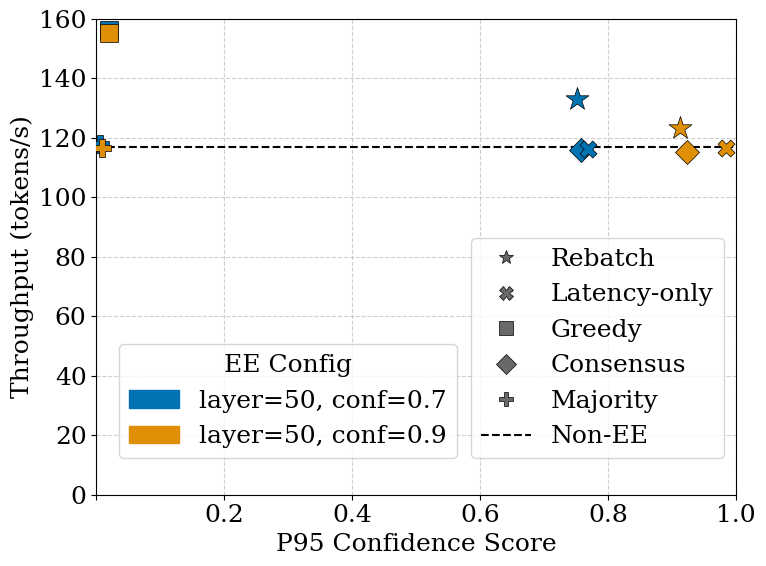

In [8]:
def plot_p95conf_vs_bert_from_csvs(data_dir):
    """
    Plots throughput vs. BERT score, creating two separate legends for
    policies (markers) and configurations (colors) stacked together in the
    upper-right corner of the figure. The "Off" policy is represented by a
    dotted horizontal line. Markers have a black outline.
    """
    plt.rc("font", size=18, family="serif")
    # Define policies, configs, and their visual properties
    policies = {
        "rebatching": {"label": "Rebatch", "marker": "*"},
        "eager": {"label": "Greedy", "marker": "s"},
        "lazy": {"label": "Consensus", "marker": "D"},
        "median": {"label": "Majority", "marker": "P"},
        "latency-only": {"label": "Latency-only", "marker": "X"},
        "off": {"label": "Non-EE"},
    }
    # Define the specific configs and their associated colors
    palette = sns.color_palette("colorblind", n_colors=2)
    config_color_map = {
        ("50", "0.7"): palette[0],
        ("50", "0.9"): palette[1],
    }

    # --- Data Preparation ---
    rows = []
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        if fname == "req_2160_batch_8_layer_50_conf_0.7_rebatching_copy.csv":
            rebatching_07_conf_score = pd.read_csv(csv_path)["p95_conf_score_ee"].mean()
            break

    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        if fname == "req_2160_batch_8_layer_50_conf_0.7_rebatching_copy.csv":
            continue
        m = re.search(r"layer_([0-9]+)_conf_([0-9.]+)_([a-z\-]+)_copy\.csv$", fname)
        if m:
            layer, conf, policy = m.group(1), m.group(2), m.group(3)

            if policy not in policies:
                continue
            if policy != 'off' and (layer, conf) not in config_color_map:
                continue
            
            try:
                df = pd.read_csv(csv_path)
            except Exception as e:
                print(f"Error reading {csv_path}: {e}")
                continue
                
            throughput = df["throughput"].mean()
            if policy == "rebatching" and conf == "0.7":
                p95_conf_score = rebatching_07_conf_score
            else:
                p95_conf_score = df["p95_conf_score_ee"].mean()
            if policy == "off":
                p95_conf_score = 1
            rows.append({
                "policy": policy,
                "layer": layer,
                "conf": conf,
                "throughput": throughput,
                "p95_conf_score": p95_conf_score,
            })

    plot_df = pd.DataFrame(rows)
    print(f"Found {len(plot_df)} data points to plot.")
    print(plot_df)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the 'off' policy as a horizontal dotted line
    subdf_off = plot_df[plot_df["policy"] == "off"]
    if not subdf_off.empty:
        off_throughput = subdf_off["throughput"].mean()
        ax.axhline(y=off_throughput, color='black', linestyle='--', zorder=2)

    # Plot data points for other policies and configs
    for policy, p_info in policies.items():
        if policy == "off":
            continue
        for (layer, conf), color in config_color_map.items():
            subdf = plot_df[
                (plot_df["policy"] == policy) &
                (plot_df["layer"] == layer) &
                (plot_df["conf"] == conf)
            ]
            if not subdf.empty:
                marker_size = 300 if policy == "rebatching" else 150
                ax.scatter(
                    subdf["p95_conf_score"], subdf["throughput"],
                    marker=p_info["marker"], 
                    color=color, 
                    s=marker_size, 
                    zorder=3,
                    # --- ADDED LINES FOR OUTLINE ---
                    edgecolors='black', # Sets the outline color
                    linewidths=0.5      # Sets the outline width
                )

    # --- Manual Legend Creation in Upper Right Corner ---

    # 1. Create handles for the "Config" legend (colors)
    config_handles = [
        mpatches.Patch(color=palette[0], label="layer=50, conf=0.7"),
        mpatches.Patch(color=palette[1], label="layer=50, conf=0.9"),
    ]
    # Create the first legend and specify its location
    config_legend = ax.legend(handles=config_handles, title="EE Config",
                              loc='lower center', bbox_to_anchor=(0.3, 0.05))

    # Add the first legend to the axes manually
    ax.add_artist(config_legend)

    # 2. Create handles for the "Policy" legend (markers and line styles)
    policy_order = ["rebatching", "latency-only", "eager", "lazy", "median", "off"]
    policy_handles = []
    for p in policy_order:
        if p == 'off':
            policy_handles.append(
                mlines.Line2D([], [], color='black', linestyle='--',
                              label=policies[p]['label'])
            )
        else:
            policy_handles.append(
                mlines.Line2D([], [], color='dimgrey', marker=policies[p]['marker'],
                              linestyle='None', markersize=10, 
                              # --- ADDED FOR LEGEND MARKER OUTLINE ---
                              markeredgecolor='black',
                              markeredgewidth=0.5,
                              label=policies[p]['label'])
            )
            
    # Create the second legend, placing it below the first one
    ax.legend(handles=policy_handles,
              loc='lower right', bbox_to_anchor=(1, 0.05))

    # --- Final Touches ---
    ax.set_xlabel("P95 Confidence Score")
    ax.set_ylabel("Throughput (tokens/s)")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_ylim(0, 160)
    ax.set_xlim(0, 1)

    labels = ax.get_xticklabels()
    for label in labels:
        if label.get_text() == '0.0':
            label.set_visible(False)
    plt.tight_layout()
    plt.savefig(f"figures/throughput_vs_conf/throughput_vs_conf_{model_setting}.pdf", bbox_inches='tight')
    plt.show()

plot_p95conf_vs_bert_from_csvs(data_dir)

In [ ]:
def plot_ee_proportion_and_throughput(data_dir):
    """
    Plots EE token proportion and throughput, including a baseline "Off" policy.

    This function creates a bar chart showing:
    - X-axis: Policies (rebatch, lazy, median, eager)
    - Left Y-axis: EE Token Proportion (%)
    - Right Y-axis: Throughput (overlaid as dots)
    - A horizontal dotted line shows the throughput of the "Off" policy.
    """
    plt.rc("font", size=18, family="serif")
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    # 1. Read baseline "Off" policy data from "off.csv"
    off_throughput = None
    off_csv_path = data_dir / "req_100_batch_8_layer_50_conf_0.9_off_copy.csv"
    if off_csv_path.exists():
        df_off = pd.read_csv(off_csv_path)
        if "throughput" in df_off.columns:
            off_throughput = df_off["throughput"].mean()
            print(f"Found 'Off' policy baseline throughput: {off_throughput:.2f}")
    else:
        print("Note: 'req_100_batch_4_layer_50_conf_0.7_off_copy.csv' not found. Skipping baseline throughput line.")

    # Define policies and their display names
    policies = {
        "rebatching": "Rebatch",
        "lazy": "Consensus",
        "median": "Majority",
        "eager": "Greedy",
        "latency-only": "Latency-only",
    }
    confs = ["0.7", "0.9"]

    # Prepare data for other policies
    rows = []
    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        if fname == "req_2160_batch_8_layer_50_conf_0.7_rebatching_copy.csv":
            continue
        m = re.search(r"conf_([0-9.]+)_([a-z\-]+)_copy\.csv$", fname)
        if m:
            conf, policy = m.group(1), m.group(2)
            if policy in policies and conf in confs:
                df = pd.read_csv(csv_path)
                total_tokens = df["num_ee_tokens"].mean() + df["num_no_ee_tokens"].mean()
                if policy == "latency-only":
                    ee_prop = 0 # Latency-only us psuedo EE
                else:
                    ee_prop = (df["num_ee_tokens"].mean() / total_tokens) * 100 if total_tokens > 0 else 0
                
                involuntary_ee_prop = (df["num_seq_would_not_ee_but_ee"].mean() / df["num_ee_tokens"].mean()) * 100 if df["num_ee_tokens"].mean()  > 0 else 0
                
                rows.append({
                    "policy": policy,
                    "conf": conf,
                    "ee_proportion": ee_prop,
                    "throughput": df["throughput"].mean(),
                })

    plot_df = pd.DataFrame(rows)
    print(f"Found {len(plot_df)} data points for main policies:\n{plot_df}")
    print(plot_df)


    # Set up the plot
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

    policy_names = list(policies.values())
    x_positions = np.arange(len(policy_names))
    bar_width = 0.35
    colors = ['#1f77b4', '#ff7f0e']

    # --- Plotting Bars and Dots ---
    for i, conf in enumerate(confs):
        x_offset = i * bar_width - bar_width / 2
        for j, policy in enumerate(policies.keys()):
            data = plot_df[(plot_df["policy"] == policy) & (plot_df["conf"] == conf)]
            if not data.empty:
                d = data.iloc[0]
                ax1.bar(j + x_offset, d["ee_proportion"], bar_width, color=colors[i], alpha=0.7)
                ax2.scatter(j + x_offset, d["throughput"], color=colors[i], s=100, marker='o', edgecolors='black', linewidth=1)

    # 2. Plot the baseline "Off" policy throughput if available
    if off_throughput is not None:
        ax2.axhline(y=off_throughput, color='black', linestyle=':', linewidth=2)

    # --- Legend Creation ---
    legend_handles = [
        mpatches.Patch(color=colors[0], label='layer=50, conf=0.7', alpha=0.7),
        mpatches.Patch(color=colors[1], label='layer=50, conf=0.9', alpha=0.7),
        #mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=9,
                      #markeredgecolor='black', label='throughput')
    ]

    # 3. Add handle for the "Off" policy line to the legend
    if off_throughput is not None:
        off_handle = mlines.Line2D([], [], color='black', linestyle=':',
                                   linewidth=2, label='Throughput of Non-EE')
        legend_handles.append(off_handle)

    ax1.legend(handles=legend_handles, loc='lower right')

    # --- Plot Customization ---
    # ax1.set_xlabel('Policies', fontweight='bold')
    ax1.set_ylabel('EE Token Proportion (%)')
    ax2.set_ylabel('Throughput (tokens/sec)')
    #ax1.set_title('EE Token Proportion and Throughput by Policy', fontweight='bold', fontsize=14)
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels(policy_names)
    ax1.tick_params()
    ax2.tick_params()
    ax1.set_ylim(0, 100)
    ax2.set_ylim(bottom=0)
    ax1.grid(True, axis='y', linestyle='--', alpha=0.6)


    fig.tight_layout()
    plt.savefig(f"figures/ee_prop/ee_prop_{model_setting}.pdf", bbox_inches='tight')
    plt.show()

plot_ee_proportion_and_throughput(data_dir)

NameError: name 'data_dir' is not defined

Found 'Off' policy baseline throughput: 116.84
Processed data for plotting:
         policy conf  ee_proportion  involuntary_ee_proportion  throughput
0  latency-only  0.7       0.000000                  57.074399  116.258160
1    rebatching  0.9      12.619119                   0.000000  123.460680
2        median  0.7       3.596671                   1.265413  117.990436
3         eager  0.7      99.876484                  26.175711  156.288567
4          lazy  0.7       0.019427                   0.000000  116.038897
5        median  0.9       0.736339                   0.263274  116.645809
6         eager  0.9      99.408252                  38.941648  155.231653
7          lazy  0.9       0.006638                   0.000000  115.219439
8  latency-only  0.9       0.000000                  64.691922  116.489893
9    rebatching  0.7      46.191146                   0.000000  133.176991


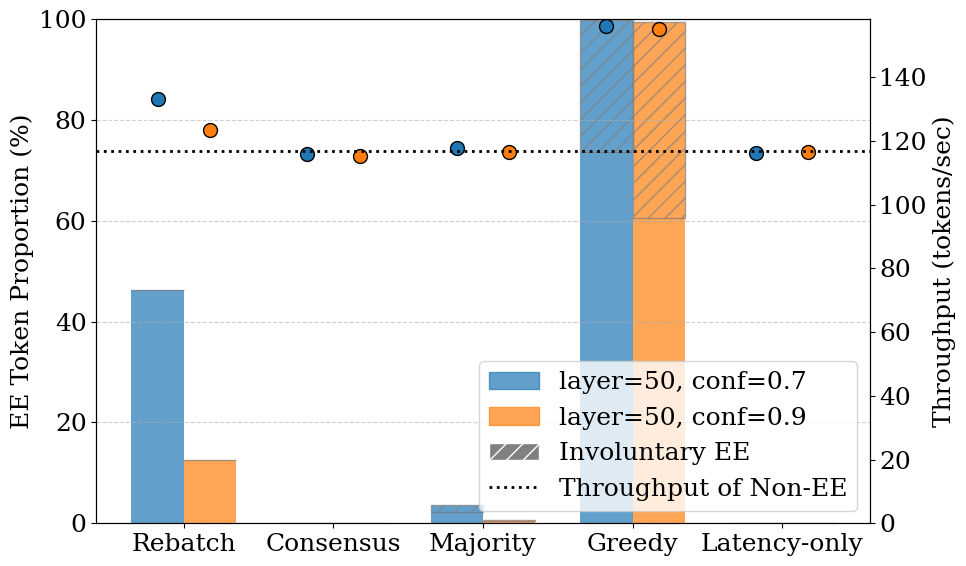

In [12]:
def plot_ee_proportion_and_throughput(data_dir, model_setting="default_model"):
    """
    Plots EE token proportion and throughput, including a baseline "Off" policy.

    This function creates a bar chart showing:
    - X-axis: Policies (rebatch, lazy, median, eager)
    - Left Y-axis: EE Token Proportion (%), with involuntary EE shown as a hatched sub-bar.
    - Right Y-axis: Throughput (overlaid as dots)
    - A horizontal dotted line shows the throughput of the "Off" policy.
    """
    plt.rc("font", size=18, family="serif")
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    # 1. Read baseline "Off" policy data from "off.csv"
    off_throughput = None
    off_csv_path = data_dir / "req_100_batch_8_layer_50_conf_0.9_off_copy.csv"
    if off_csv_path.exists():
        df_off = pd.read_csv(off_csv_path)
        if "throughput" in df_off.columns:
            off_throughput = df_off["throughput"].mean()
            print(f"Found 'Off' policy baseline throughput: {off_throughput:.2f}")
    else:
        print("Note: 'req_100_batch_4_layer_50_conf_0.7_off_copy.csv' not found. Skipping baseline throughput line.")

    # Define policies and their display names
    policies = {
        "rebatching": "Rebatch",
        "lazy": "Consensus",
        "median": "Majority",
        "eager": "Greedy",
        "latency-only": "Latency-only",
    }
    confs = ["0.7", "0.9"]

    # Prepare data for other policies
    rows = []
    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        if fname == "req_2160_batch_8_layer_50_conf_0.7_rebatching_copy.csv":
            continue
        m = re.search(r"conf_([0-9.]+)_([a-z\-]+)_copy\.csv$", fname)
        if m:
            conf, policy = m.group(1), m.group(2)
            if policy in policies and conf in confs:
                df = pd.read_csv(csv_path)
                total_tokens = df["num_ee_tokens"].mean() + df["num_no_ee_tokens"].mean()
                if policy == "latency-only":
                    ee_prop = 0 # Latency-only is pseudo EE
                else:
                    ee_prop = (df["num_ee_tokens"].mean() / total_tokens) * 100 if total_tokens > 0 else 0
                
                # MODIFICATION: Calculate involuntary proportion relative to TOTAL tokens for correct stacking
                involuntary_ee_prop = (df["num_seq_would_not_ee_but_ee"].mean() / total_tokens) * 100 if total_tokens > 0 else 0
                
                rows.append({
                    "policy": policy,
                    "conf": conf,
                    "ee_proportion": ee_prop, # Total height of the bar
                    "involuntary_ee_proportion": involuntary_ee_prop, # Height of the hatched part
                    "throughput": df["throughput"].mean(),
                })

    plot_df = pd.DataFrame(rows)
    print("Processed data for plotting:")
    print(plot_df)

    # Set up the plot
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

    policy_names = list(policies.values())
    x_positions = np.arange(len(policy_names))
    bar_width = 0.35
    colors = ['#1f77b4', '#ff7f0e']

    # --- Plotting Bars and Dots ---
    for i, conf in enumerate(confs):
        x_offset = i * bar_width - bar_width / 2
        for j, policy in enumerate(policies.keys()):
            data = plot_df[(plot_df["policy"] == policy) & (plot_df["conf"] == conf)]
            if not data.empty:
                d = data.iloc[0]
                
                # MODIFICATION: Plot stacked bars for voluntary and involuntary proportions
                total_ee_prop = d["ee_proportion"]
                involuntary_prop = d["involuntary_ee_proportion"]
                voluntary_prop = total_ee_prop - involuntary_prop
                
                # 1. Plot the voluntary (bottom) part of the bar
                ax1.bar(j + x_offset, voluntary_prop, bar_width, color=colors[i], alpha=0.7)
                
                # 2. Plot the involuntary (top, hatched) part of the bar
                ax1.bar(j + x_offset, involuntary_prop, bar_width, bottom=voluntary_prop, color=colors[i], alpha=0.7, hatch='//', edgecolor='gray')

                # Plot throughput on the secondary axis
                ax2.scatter(j + x_offset, d["throughput"], color=colors[i], s=100, marker='o', edgecolors='black', linewidth=1)

    # Plot the baseline "Off" policy throughput if available
    if off_throughput is not None:
        ax2.axhline(y=off_throughput, color='black', linestyle=':', linewidth=2)

    # --- Legend Creation ---
    legend_handles = [
        mpatches.Patch(color=colors[0], label='layer=50, conf=0.7', alpha=0.7),
        mpatches.Patch(color=colors[1], label='layer=50, conf=0.9', alpha=0.7),
        # MODIFICATION: Add a legend entry to explain the hatching
        mpatches.Patch(facecolor='gray', hatch='//', edgecolor='white', label='Involuntary EE'),
    ]

    # Add handle for the "Off" policy line to the legend
    if off_throughput is not None:
        off_handle = mlines.Line2D([], [], color='black', linestyle=':',
                                   linewidth=2, label='Throughput of Non-EE')
        legend_handles.append(off_handle)

    ax1.legend(handles=legend_handles, loc='lower right')

    # --- Plot Customization ---
    ax1.set_ylabel('EE Token Proportion (%)')
    ax2.set_ylabel('Throughput (tokens/sec)')
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels(policy_names)
    ax1.tick_params()
    ax2.tick_params()
    ax1.set_ylim(0, 100)
    ax2.set_ylim(bottom=0)
    ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

    fig.tight_layout()
    # Ensure the 'figures/ee_prop' directory exists
    Path("figures/ee_prop").mkdir(parents=True, exist_ok=True)
    plt.savefig(f"figures/ee_prop/ee_prop_{model_setting}.pdf", bbox_inches='tight')
    plt.show()


plot_ee_proportion_and_throughput(data_dir, model_setting=model_setting)

Found the following data points:
       policy conf  throughput  bert_score
0  rebatching  0.7  128.590614    0.782348
1  rebatching  0.9  123.460680    0.802941
2         off  0.7  115.933282    0.815496
3      median  0.7  117.990436    0.807615
4       eager  0.7  156.288567    0.711175
5      median  0.9  116.645809    0.812652
6       eager  0.9  155.231653    0.711268

Baseline 'Off' throughput: 115.93, BERT score: 0.8155


/tmp/ipykernel_2689921/627258880.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(policies.values())


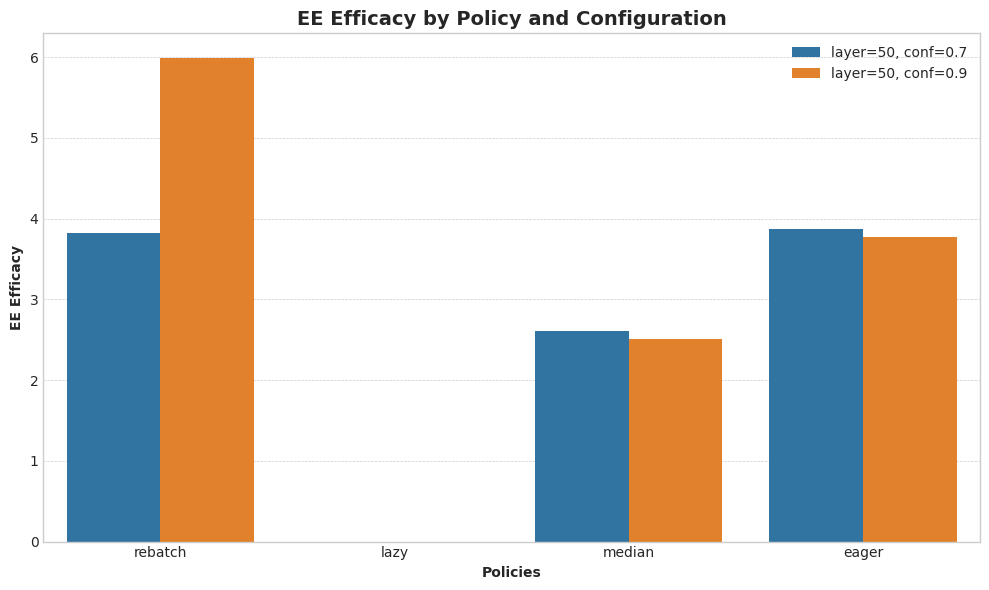

In [17]:
def plot_ee_efficacy(data_dir: Path):
    """
    Plots EE efficacy by policy and configuration.

    This function creates a grouped bar chart showing:
    - X-axis: Policies (rebatch, lazy, median, eager)
    - Y-axis: EE efficacy, calculated relative to a baseline 'off' policy.
    - Each policy has two grouped bars representing different configurations.
    """
    # Define policies and their display names
    policies = {
        "rebatching": "rebatch",
        "lazy": "lazy",
        "median": "median",
        "eager": "eager"
    }

    # Prepare data
    rows = []
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        # The 'off' policy is used as a baseline and has a different filename format
        if fname == "req_100_batch_4_layer_50_conf_0.7_off_copy.csv":
            policy_key = "off"
            conf = "N/A" # Confidence is not applicable to the 'off' policy
        else:
            m = re.search(r"conf_([0-9.]+)_([a-z]+)_copy\.csv$", fname)
            if not m:
                continue
            conf, policy_key = m.group(1), m.group(2)
        
        if policy_key == "lazy":
            continue

        # Skip files that don't match our policies of interest
        if policy_key not in policies and policy_key != "off":
            continue

        df = pd.read_csv(csv_path)
        rows.append({
            "policy": policy_key,
            "conf": conf,
            "throughput": df["throughput"].mean(),
            "bert_score": df["bert_score"].mean(),
        })

    if not rows:
        print("No data found. Check your data directory and file naming.")
        return

    plot_df = pd.DataFrame(rows)
    print("Found the following data points:")
    print(plot_df)

    # Extract baseline values from the 'off' policy
    try:
        off_policy_data = plot_df[plot_df["policy"] == "off"].iloc[0]
        off_throughput = off_policy_data["throughput"]
        off_bert_score = off_policy_data["bert_score"]
        print(f"\nBaseline 'Off' throughput: {off_throughput:.2f}, BERT score: {off_bert_score:.4f}")
    except IndexError:
        print("Error: Baseline 'off.csv' data not found. Cannot calculate efficacy.")
        return

    # Filter out the 'off' policy before calculating efficacy for the other policies
    plot_df = plot_df[plot_df["policy"] != "off"].copy()
    # Efficacy: Throughput gain per 0.01 drop in BERT score
    plot_df["ee_efficacy"] = (plot_df["throughput"] - off_throughput) / ((off_bert_score - plot_df["bert_score"]) * 100)

    # --- Plotting ---
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(10, 6))

    # 1. Use the specified colorblind-friendly palette
    colors = ['#1f77b4', '#ff7f0e']

    ax = sns.barplot(
        data=plot_df,
        x='policy',
        y='ee_efficacy',
        hue='conf',
        order=list(policies.keys()),
        palette=colors
    )

    # Customize the plot
    ax.set_xlabel('Policies', fontweight='bold')
    ax.set_ylabel('EE Efficacy', fontweight='bold')
    ax.set_title('EE Efficacy by Policy and Configuration', fontweight='bold', fontsize=14)
    ax.set_xticklabels(policies.values())
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y')

    # 2. Customize legend with specified labels
    handles, _ = ax.get_legend_handles_labels()
    new_labels = ['layer=50, conf=0.7', 'layer=50, conf=0.9']
    ax.legend(handles, new_labels)

    plt.tight_layout()
    plt.show()

plot_ee_efficacy(data_dir)

In [32]:
def get_summary_table_from_csvs(data_dir):
    """
    Plots throughput vs. BERT score, creating two separate legends for
    policies (markers) and configurations (colors) stacked together in the
    upper-right corner of the figure.
    """
    # Define policies, configs, and their visual properties
    policies = {
        "rebatching": {"label": "Rebatch", "marker": "*"},
        "eager": {"label": "Greedy", "marker": "s"},
        "lazy": {"label": "Consensus", "marker": "D"},
        "median": {"label": "Majority", "marker": "P"},
        "latency-only": {"label": "Latency-only", "marker": "X"},
        "off": {"label": "Off", "marker": "o"},
    }
    # Define the specific configs and their associated colors
    palette = sns.color_palette("colorblind", n_colors=2)
    config_color_map = {
        ("50", "0.7"): palette[0],
        ("50", "0.9"): palette[1],
    }

    # --- Data Preparation ---
    rows = []
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        m = re.search(r"layer_([0-9]+)_conf_([0-9.]+)_([a-z\-]+)_copy\.csv$", fname)
        if m:
            layer, conf, policy = m.group(1), m.group(2), m.group(3)

            print(f"Processing {policy}")

            if policy not in policies:
                continue
            if policy != 'off' and (layer, conf) not in config_color_map:
                continue
            
            try:
                df = pd.read_csv(csv_path)
            except:
                print(f"Error reading {csv_path}")
                
            
            throughput = df["throughput"].mean()
            p95_conf_score = df["p95_conf_score_ee"].mean()
            if policy == "off":
                p95_conf_score = 1
            bert_score = df["bert_score"].mean()
            throughput_times_p95_conf_score = throughput * p95_conf_score
            throughput_times_bert_score = throughput * bert_score

            total_tokens = df["num_ee_tokens"].mean() + df["num_no_ee_tokens"].mean()
            ee_proportion = (df["num_ee_tokens"].mean() / total_tokens) if total_tokens > 0 else 0

            involuntary_stay_proportion = (df["num_seq_would_ee_but_stay"].mean() / df["num_no_ee_tokens"].mean()) if df["num_no_ee_tokens"].mean() > 0 else 0
            involuntary_ee_proportion = (df["num_seq_would_not_ee_but_ee"].mean() / df["num_ee_tokens"].mean()) if df["num_ee_tokens"].mean() > 0 else 0

            itl_p95 = df["tbt_p95"].mean()
            itl_p99 = df["tbt_p99"].mean()
            
            request_duration_p95 = df["request_duration_p95"].mean()
            request_duration_p99 = df["request_duration_p99"].mean()

            request_duration_avg = df["request_duration_avg"].mean()

            rows.append({
                "policy": policy,
                "layer": layer,
                "conf": conf,
                "throughput": throughput,
                "bert_score": bert_score,
                "p95_conf_score": p95_conf_score,
                "throughput_times_p95_conf_score": throughput_times_p95_conf_score,
                "throughput_times_bert_score": throughput_times_bert_score,
                "ee_proportion": ee_proportion,
                "involuntary_stay_proportion": involuntary_stay_proportion,
                "involuntary_ee_proportion": involuntary_ee_proportion,
                "itl_p95": itl_p95,
                "itl_p99": itl_p99,
                "request_duration_p95": request_duration_p95,
                "request_duration_p99": request_duration_p99,
                "request_duration_avg": request_duration_avg,
            })

    plot_df = pd.DataFrame(rows)
    print(f"Found {len(plot_df)} data points to plot.")
    #print(plot_df)
    return plot_df

    
get_summary_table_from_csvs(data_dir)

Processing rebatching
Processing latency-only
Processing rebatching
Processing median
Processing eager
Processing lazy
Processing median
Processing eager
Processing lazy
Processing latency-only
Processing off
Found 11 data points to plot.


,policy,layer,conf,throughput,bert_score,p95_conf_score,throughput_times_p95_conf_score,throughput_times_bert_score,ee_proportion,involuntary_stay_proportion,involuntary_ee_proportion,itl_p95,itl_p99,request_duration_p95,request_duration_p99,request_duration_avg
0,rebatching,50,0.7,128.590614,0.782348,0.750488,96.505749,100.602633,0.371815,0.022614,0.000000,0.063132,0.076425,31.160230,33.998371,20.630036
1,latency-only,50,0.7,116.258160,0.787181,0.767920,89.276957,91.516192,0.988024,0.000000,0.577662,0.064576,0.065351,17.805854,18.057801,11.022174
2,rebatching,50,0.9,123.460680,0.802941,0.912109,112.609644,99.131634,0.126191,0.051458,0.000000,0.076014,0.079170,28.355175,30.125912,19.436390
3,median,50,0.7,117.990436,0.807615,0.006344,0.748558,95.290818,0.035967,0.255038,0.351829,0.064584,0.065356,17.511100,17.735414,11.206362
4,eager,50,0.7,156.288567,0.711175,0.020325,3.176519,111.148520,0.998765,0.000000,0.262081,0.049362,0.049917,13.343621,13.440684,12.713082
5,lazy,50,0.7,116.038897,0.815048,0.758008,87.958391,94.577317,0.000194,0.310654,0.000000,0.064180,0.064735,17.638605,17.926400,10.039385
6,median,50,0.9,116.645809,0.812652,0.008781,1.024317,94.792426,0.007363,0.180536,0.357544,0.064182,0.064653,17.627886,17.918898,10.586716
7,eager,50,0.9,155.231653,0.711268,0.019917,3.091677,110.411341,0.994083,0.000000,0.391735,0.049684,0.050851,13.359430,13.599309,12.730952
8,lazy,50,0.9,115.219439,0.815483,0.922852,106.330439,93.959496,0.000066,0.195129,0.000000,0.064812,0.065532,17.738601,18.143547,10.008502
9,latency-only,50,0.9,116.489893,0.801327,0.984668,114.703867,93.346507,0.898513,0.000000,0.719989,0.064312,0.065298,17.690321,18.065320,10.832521


In [ ]:
latency is something we can control:
1. priortize SLA deadline
2. push even firther --> EE SLA deadline